In [14]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import os
os.getcwd()

# os.chdir("/home/jovyan/work/CN_A1_StructuralDescriptors")
os.chdir("/home/jovyan/work")
print(os.getcwd())
print(os.listdir())


/home/jovyan/work
['.git', 'A1-Log-Log-Histograms.pdf', 'activityA1', 'notebooks']


## Network 1

In [15]:
G_raw = nx.read_pajek('activityA1/net1.net')
G = nx.Graph(G_raw)

### Part 1

#### Nodes & Edges

In [16]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(num_nodes)
print(num_edges)

5000
25000


#### Min, Max and Avg degree

In [17]:
degrees = [degree for node, degree in G.degree()]
min_deg = np.min(degrees)
max_deg = np.max(degrees)
avg_deg = np.mean(degrees)
print(f"Grado mínimo: {min_deg}")
print(f"Grado máximo: {max_deg}")
print(f"Grado promedio: {avg_deg:.2f}")

Grado mínimo: 6
Grado máximo: 16
Grado promedio: 10.00


#### Avg clustering coeficient

In [18]:
avg_clustering = nx.average_clustering(G)
print(f"Average clustering: {avg_clustering:.4f}")

transitivity = nx.transitivity(G)
print(f"Transitivity: {transitivity:.4f}")

Average clustering: 0.4141
Transitivity: 0.4032


#### Assortativity

In [7]:
assortativity = nx.degree_assortativity_coefficient(G)
print(f"Assortativity: {assortativity:.4f}")

Assortativity: -0.0097


#### Average path lenght & Diameter

In [8]:
if nx.is_connected(G):
    G_main = G
else:
    print("Net is disconected")
    largest_cc = max(nx.connected_components(G), key=len)
    G_main = G.subgraph(largest_cc)

avg_path = nx.average_shortest_path_length(G_main)
diameter = nx.diameter(G_main)
print(f"Average path lenght {avg_path:.4f}")
print(f"Diameter: {diameter}")


Average path lenght 5.1211
Diameter: 8


#### Degree distribution

In the case of the network 1 the linear distribution shows perfectly the data

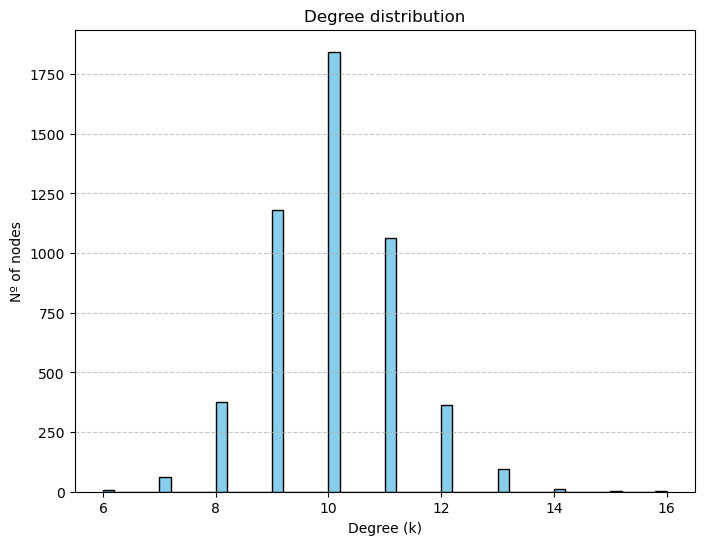

In [9]:
degrees = [degree for node, degree in G.degree()]

plt.figure(figsize=(8, 6))

plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')

plt.title('Degree distribution')
plt.xlabel('Degree (k)')
plt.ylabel('Nº of nodes')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

#### Degree centrality

In [10]:
def get_top_5(centrality_dict):
    return sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)[:5]

deg_cent = nx.degree_centrality(G)
print("\nTop 5 - Degree Centrality:")
for node, val in get_top_5(deg_cent):
    print(f"Node {node}: {val:.4f}")


Top 5 - Degree Centrality:
Node 1693: 0.0032
Node 651: 0.0030
Node 1579: 0.0030
Node 4891: 0.0030
Node 41: 0.0028


#### Eigenvector centrality

In [11]:
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
    print("\nTop 5 - Eigenvector Centrality:")
    for node, val in get_top_5(eig_cent):
        print(f"Node {node}: {val:.4f}")
except nx.PowerIterationFailedConvergence:
    print("\nFailed on convergence")


Top 5 - Eigenvector Centrality:
Node 651: 0.0286
Node 1937: 0.0265
Node 4526: 0.0256
Node 4398: 0.0253
Node 1939: 0.0252


#### Betweeness centrality

In [12]:
bet_cent = nx.betweenness_centrality(G) 
print("\nTop 5 - Betweenness Centrality:")
for node, val in get_top_5(bet_cent):
    print(f"Node {node}: {val:.4f}")


Top 5 - Betweenness Centrality:
Node 4747: 0.0041
Node 2645: 0.0040
Node 230: 0.0038
Node 4360: 0.0038
Node 1579: 0.0037


#### Conclusions

For the network 1 the top nodes hardly ever repeat in the different measures, so there is a diferent top node for each centrality. This could mean that the network is totally random.

### Part 2

We believe that Network 1 follows the WS model. 

This is because a large clustering and a small path lenght simultaneously.